In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



df = pd.read_csv("../Data/IMDB Dataset.csv")




print(df.head())
print('-'*20)
print(df.describe())
print('-'*20)
print(df.info())
print('-'*20)
print(df.isnull().sum())
print('-'*20)
print(df.duplicated().sum())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
--------------------
                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive
freq                                                    5     25000
--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment 

In [2]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [3]:
df = df.drop_duplicates()

In [4]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

1310.5682304061959
13704
32


<Axes: xlabel='text_length', ylabel='Count'>

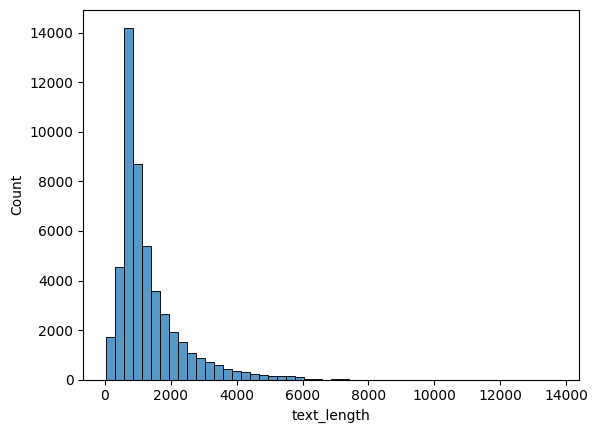

In [5]:
df['text_length'] = [len(text) for text in df['review']]

df['text_length'].astype(float)

print(df['text_length'].mean())
print(df['text_length'].max())
print(df['text_length'].min())

sns.histplot(x = df['text_length'] , bins=50)

In [6]:
# preprocessing text

Q1 = df['text_length'].quantile(0.25)
Q3 = df['text_length'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

In [7]:
df = df[
   df['text_length'].between(lower_fence , upper_fence)
]

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45877 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review       45877 non-null  object
 1   sentiment    45877 non-null  object
 2   text_length  45877 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


In [9]:
# EDA for text
ranged = [175 , 24 , 637 , 288 , 1672]

random_data = []

for i in ranged:
    data = df.loc[i]
    random_data.append(data)

random_data1 = pd.DataFrame(random_data)

for text in random_data1['review']:
    print(text)
    print('-'*20)

Why can't a movie be rated a zero? Or even a negative number? Some movies such as "Plan Nine From Outer Space" are so bad they're fun to watch. THIS IS NOT ONE. "The Dungeon of Horror" might be the worst movie I've ever seen (some of anyway. I HAD to fast forward through a lot of it!). Fortunately for the indiscretions of my youth and senility of my advancing age, there may be worse movies I've seen, but thankfully, I can't remember them. The sets appeared to be made with cardboard and finished with cans of spray paint. The special effects looked like a fifth grader's C+ diorama set in a shoebox. The movie contained unforgivable gaffs such as when the Marquis shoots and kills his servant. He then immediately gets into a scuffle with his escaping victim, who takes his flintlock and shoots him with it, without the gun having been reloaded! This movie was so bad my DVD copy only had name credits. I guess no company or studio wanted to be incriminated. Though I guess when you film in your 

In [10]:
df.to_csv('../Data/preprocessed_data.csv')